In [1]:
%reload_ext autoreload
%autoreload 2
import py4DSTEM
import numpy as np
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import gaussian_kde
from matplotlib import ticker
from microstructure_inference.dataModules import cubic_proper_point_group_operations
from microstructure_inference.dataProcessing import point_in_spherical_triangle_oriented, assignment_cost_pairwise_distance,  sample_rotation_at_rand_geodesic_distance
from py4DSTEM.process.diffraction.utils import OrientationMap, Orientation
from microstructure_inference.analysis.measure_correlation_score import measure_sparseCorr_of_single_pattern, orientation_plan_init_for_single_pattern, Q_calculation


# %matplotlib qt
# plt.ion()

# Define helper function

In [2]:

def measure_angle_between_vectors(
                                vec_1: np.ndarray, 
                                vec_2: np.ndarray, 
                                returnCosAngle = True,
                                degrees: bool = False
) -> float:
    """
    Compute the angle between two 3D vectors using the dot product.

    Parameters
    ----------
    vec_1 : np.ndarray
        First vector, shape (3,)
    vec_2 : np.ndarray
        Second vector, shape (3,)
    degrees : bool, optional
        If True, return the angle in degrees. Otherwise, return radians.

    Returns
    -------
    float
        The angle between the two vectors.
    """
    # Ensure inputs are numpy arrays
    vec_1 = np.asarray(vec_1)
    vec_2 = np.asarray(vec_2)

    # Compute dot product and norms
    dot_product = np.dot(vec_1, vec_2)
    norm_1 = np.linalg.norm(vec_1)
    norm_2 = np.linalg.norm(vec_2)

    # Avoid division by zero
    if norm_1 == 0 or norm_2 == 0:
        raise ValueError("Input vectors must be non-zero.")

    # Compute cosine of the angle with clipping to handle numerical errors
    cos_theta = np.clip(dot_product / (norm_1 * norm_2), -1.0, 1.0)

    # Compute the angle
    theta = np.arccos(cos_theta)

    # Optionally convert to degrees
    if degrees:
        theta = np.degrees(theta)

    if returnCosAngle:
        return theta, cos_theta

    return theta

def plot_scatter_projection(ax, data1, data2, loc=0, axis_type='z', color='blue', alpha=0.2, s=1):
    """
    Project 2D scatter onto a plane in 3D space.
    
    axis_type: 'z' -> XY plane at Z=loc
               'x' -> YZ plane at X=loc
               'y' -> XZ plane at Y=loc
    """
    if axis_type == 'z':
        # XY plane at Z=loc
        ax.scatter(data1, data2, np.full_like(data1, loc), c=color, alpha=alpha, s=s)
    elif axis_type == 'x':
        # YZ plane at X=loc
        ax.scatter(np.full_like(data1, loc), data1, data2, c=color, alpha=alpha, s=s)
    elif axis_type == 'y':
        # XZ plane at Y=loc
        ax.scatter(data1, np.full_like(data1, loc), data2, c=color, alpha=alpha, s=s)



def plot_density_map(ax, data1, data2, bins=500, loc=0, axis_type='z', cmap='viridis'):
    """Helper function to calculate and plot a 2D density map."""
    # Create the 2D histogram/density
    hist, xedges, yedges = np.histogram2d(data1, data2, bins=bins, density=False)
    
    # Calculate the center points of the bins for plotting
    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    
    # Create the meshgrid for the surface plot
    X_mesh, Y_mesh = np.meshgrid(x_centers, y_centers)

    # Use a ScalarMappable to apply colors based on the histogram values
    # The histogram is transposed for coloring consistency with meshgrid
    sm = plt.cm.ScalarMappable(cmap=cmap)
    
    if axis_type == 'z':
        # Projection on the XY plane (Floor) -> Z is constant at 'loc'
        # FIX: Create a 2D array of constant 'loc' to match the meshgrid shape
        Z_const = np.full_like(X_mesh, loc) 
        # hist.T is used for coloring the surface
        ax.plot_surface(X_mesh, Y_mesh, Z_const, rstride=1, cstride=1, facecolors=sm.to_rgba(hist.T), shade=False, alpha=1)
    elif axis_type == 'x':
        # Projection on the YZ plane (Side wall) -> X is constant at 'loc'
        # Y (data1) and Z (data2) are the plotting axes. X is constant.
        Y_mesh_YZ, Z_mesh_YZ = np.meshgrid(x_centers, y_centers) 
        X_const = np.full_like(Y_mesh_YZ, loc)
        # We need to make sure the facecolors array matches the shape of Y_mesh_YZ and Z_mesh_YZ
        ax.plot_surface(X_const, Y_mesh_YZ, Z_mesh_YZ, rstride=1, cstride=1, facecolors=sm.to_rgba(hist.T), shade=False, alpha=1)
    elif axis_type == 'y':
        # Projection on the XZ plane (Back wall) -> Y is constant at 'loc'
        # X (data1) and Z (data2) are the plotting axes. Y is constant.
        X_mesh_XZ, Z_mesh_XZ = np.meshgrid(x_centers, y_centers) 
        Y_const = np.full_like(X_mesh_XZ, loc)
        ax.plot_surface(X_mesh_XZ, Y_const, Z_mesh_XZ, rstride=1, cstride=1, facecolors=sm.to_rgba(hist.T), shade=False, alpha=1)



In [3]:

model_path = os.getcwd() + "/"
geodesic_loss_path = model_path + "panel_d/"
data_path = model_path + "../"

panel_e_directory_path = model_path + "panel_e/"
panel_f_directory_path = model_path + "panel_f/"
panel_g_directory_path = model_path + "panel_g/"



Cu_cif = "Cu_fcc.cif"

pixel_size = 0.0328
excitation_error = 0.02
pixel_numbers = 128


num_matches_return = 1
match_ind = 0
num_matches_return = 1
correlation_thr = 100.

k_max = pixel_size * pixel_numbers / 2.
range_plot = [k_max, k_max]
accelerating_voltage = int(300e3)
crystal = py4DSTEM.process.diffraction.Crystal.from_CIF(data_path + Cu_cif)
crystal.setup_diffraction(accelerating_voltage)
crystal.calculate_structure_factors(
    k_max,
)

# # Create an orientation plan for [0001] WS2
# crystal.orientation_plan(
#     angle_step_zone_axis = 1,
#     angle_step_in_plane = 1,
#     accel_voltage = 300e3,
#     corr_kernel_size= 0.08, # was 0.08 before 0.12 not bad
#     zone_axis_range='auto',
# )

# Create an orientation plan for [0001] WS2
crystal.orientation_plan(
    angle_step_zone_axis = 2,
    angle_step_in_plane = 2,
    accel_voltage = 300e3,
    corr_kernel_size= 0.08, # was 0.08 before 0.12 not bad
    zone_axis_range='auto',
)

# crystal.plot_orientation_zones(
#     figsize = (8,8),    
# )

# crystal.orientation_vecs

Automatically detected point group m-3m,
 using arguments: zone_axis_range = 
[[0 1 1]
 [1 1 1]], 
 fiber_axis=None, fiber_angles=None.
self.orientation_refine
 False 



Orientation plan: 100%|█████████████| 406/406 [00:00<00:00, 4837.47 zone axes/s]


In [4]:
test_set_label_rotation_matrices = np.load(data_path + "orientation_original_labels_test.npy")
test_set_predi_rotation_matrices = np.load(geodesic_loss_path + "predicted_rotation_matrices_trained_test_canonical.npy")
test_set_geodesic_distances_trained = np.load(geodesic_loss_path + "geodesic_distances_trained_test.npy")


index_of_DP_with_high_geodesic_loss_val = []
geodesic_distance_threshold = 0.6

for geo_idx, geo_val in enumerate(test_set_geodesic_distances_trained):
    if geo_val > geodesic_distance_threshold:
        index_of_DP_with_high_geodesic_loss_val.append(geo_idx)

        


index_of_DP_with_high_geodesic_loss_val = np.array(index_of_DP_with_high_geodesic_loss_val)
corresponding_geodesic_distances = test_set_geodesic_distances_trained[index_of_DP_with_high_geodesic_loss_val]
index_of_DP_with_high_geodesic_loss_val

array([   20,    22,    29, ..., 65506, 65521, 65528], shape=(9041,))

# symmetry reduction and find angles for, x, y, and z axis

In [5]:
test_set_label_rotation_matrices.shape, test_set_predi_rotation_matrices.shape

((65536, 3, 3), (65536, 3, 3))

In [6]:

symmetry_reduced_x_axis_angle_misalignment_degree = []
symmetry_reduced_x_axis_cosine_angle = []

symmetry_reduced_y_axis_angle_misalignment_degree = []
symmetry_reduced_y_axis_cosine_angle = []

symmetry_reduced_z_axis_angle_misalignment_degree = []
symmetry_reduced_z_axis_cosine_angle = []

for idx in range(len(test_set_label_rotation_matrices)):


    rotation_matrix_test_set_label = test_set_label_rotation_matrices[idx]
    rotation_matrix_test_set_predi = test_set_predi_rotation_matrices[idx]

    orientation_label = Orientation(num_matches=num_matches_return)
    orientation_label.matrix[match_ind] = rotation_matrix_test_set_label
    orientation_label = crystal.symmetry_reduce_directions(
                        orientation_label,
                        match_ind=match_ind,
                    )

    symmetry_reduced_orientation_family_label = orientation_label.family[0]

    x_axis_family_label = np.copy(symmetry_reduced_orientation_family_label[:,0])
    y_axis_family_label = np.copy(symmetry_reduced_orientation_family_label[:,1])
    z_axis_family_label = np.copy(symmetry_reduced_orientation_family_label[:,2])

    


    orientation_predi = Orientation(num_matches=num_matches_return)
    orientation_predi.matrix[match_ind] = rotation_matrix_test_set_predi
    orientation_predi = crystal.symmetry_reduce_directions(
                        orientation_predi,
                        match_ind=match_ind,
                    )

    symmetry_reduced_orientation_family_predi = orientation_predi.family[0]

    x_axis_family_predi = np.copy(symmetry_reduced_orientation_family_predi[:,0])
    y_axis_family_predi = np.copy(symmetry_reduced_orientation_family_predi[:,1])
    z_axis_family_predi = np.copy(symmetry_reduced_orientation_family_predi[:,2])



    del orientation_label, orientation_predi, symmetry_reduced_orientation_family_label, symmetry_reduced_orientation_family_predi


    ## measure x_axis_angle and cos_angle
    x_axis_angle_degree, x_axis_cos_angle = measure_angle_between_vectors(x_axis_family_label, x_axis_family_predi, returnCosAngle = True, degrees = True)
    y_axis_angle_degree, y_axis_cos_angle = measure_angle_between_vectors(y_axis_family_label, y_axis_family_predi, returnCosAngle = True, degrees = True)
    z_axis_angle_degree, z_axis_cos_angle = measure_angle_between_vectors(z_axis_family_label, z_axis_family_predi, returnCosAngle = True, degrees = True)


    symmetry_reduced_x_axis_angle_misalignment_degree.append(x_axis_angle_degree)
    symmetry_reduced_y_axis_angle_misalignment_degree.append(y_axis_angle_degree)
    symmetry_reduced_z_axis_angle_misalignment_degree.append(z_axis_angle_degree)
    
    symmetry_reduced_x_axis_cosine_angle.append(x_axis_cos_angle)
    symmetry_reduced_y_axis_cosine_angle.append(y_axis_cos_angle)
    symmetry_reduced_z_axis_cosine_angle.append(z_axis_cos_angle)

    

        


        

        


        
        

    
    

In [7]:
symmetry_reduced_x_axis_angle_misalignment_degree = np.array(symmetry_reduced_x_axis_angle_misalignment_degree)
symmetry_reduced_y_axis_angle_misalignment_degree = np.array(symmetry_reduced_y_axis_angle_misalignment_degree)
symmetry_reduced_z_axis_angle_misalignment_degree = np.array(symmetry_reduced_z_axis_angle_misalignment_degree)


symmetry_reduced_x_axis_cosine_angle = np.array(symmetry_reduced_x_axis_cosine_angle)
symmetry_reduced_y_axis_cosine_angle = np.array(symmetry_reduced_y_axis_cosine_angle)
symmetry_reduced_z_axis_cosine_angle = np.array(symmetry_reduced_z_axis_cosine_angle)

np.save(panel_f_directory_path + "symmetry_reduced_x_axis_angle_misalignment_degree.npy", symmetry_reduced_x_axis_angle_misalignment_degree)
np.save(panel_f_directory_path + "symmetry_reduced_y_axis_angle_misalignment_degree.npy", symmetry_reduced_y_axis_angle_misalignment_degree)
np.save(panel_f_directory_path + "symmetry_reduced_z_axis_angle_misalignment_degree.npy", symmetry_reduced_z_axis_angle_misalignment_degree)

np.save(panel_f_directory_path + "symmetry_reduced_x_axis_cosine_angle.npy", symmetry_reduced_x_axis_cosine_angle)
np.save(panel_f_directory_path + "symmetry_reduced_y_axis_cosine_angle.npy", symmetry_reduced_y_axis_cosine_angle)
np.save(panel_f_directory_path + "symmetry_reduced_z_axis_cosine_angle.npy", symmetry_reduced_z_axis_cosine_angle)

In [8]:

symmetry_reduced_x_axis_angle_misalignment_degree = np.load(panel_f_directory_path + "symmetry_reduced_x_axis_angle_misalignment_degree.npy")
symmetry_reduced_y_axis_angle_misalignment_degree = np.load(panel_f_directory_path + "symmetry_reduced_y_axis_angle_misalignment_degree.npy")
symmetry_reduced_z_axis_angle_misalignment_degree = np.load(panel_f_directory_path + "symmetry_reduced_z_axis_angle_misalignment_degree.npy")

symmetry_reduced_x_axis_cosine_angle = np.load(panel_f_directory_path + "symmetry_reduced_x_axis_cosine_angle.npy")
symmetry_reduced_y_axis_cosine_angle = np.load(panel_f_directory_path + "symmetry_reduced_y_axis_cosine_angle.npy")
symmetry_reduced_z_axis_cosine_angle = np.load(panel_f_directory_path + "symmetry_reduced_z_axis_cosine_angle.npy")


In [9]:
np.min(np.array([np.min(symmetry_reduced_x_axis_cosine_angle), np.min(symmetry_reduced_x_axis_cosine_angle), np.min(symmetry_reduced_z_axis_cosine_angle)]))

np.float64(0.6422966651606937)

In [10]:
np.max(np.array([np.max(symmetry_reduced_x_axis_cosine_angle), np.max(symmetry_reduced_x_axis_cosine_angle), np.max(symmetry_reduced_z_axis_cosine_angle)]))

np.float64(0.9999999998406874)

In [11]:
np.max(np.array([np.max(symmetry_reduced_x_axis_angle_misalignment_degree), np.max(symmetry_reduced_x_axis_angle_misalignment_degree), np.max(symmetry_reduced_x_axis_angle_misalignment_degree)]))

np.float64(47.344760364382644)

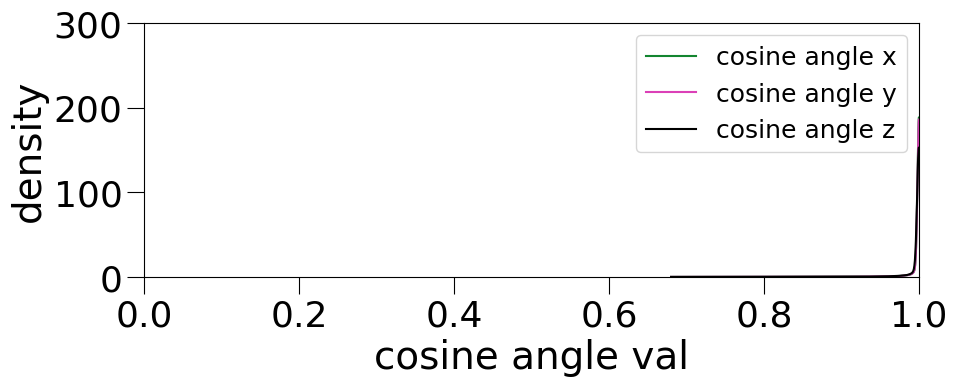

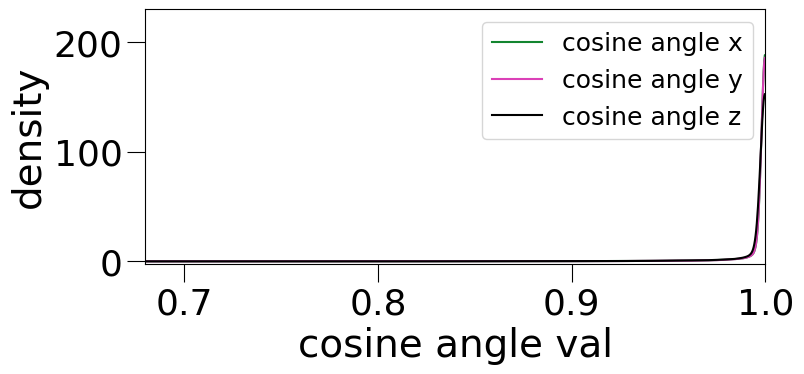

In [12]:

# Create KDE
lower_bound = 0.68
upper_bound = 1.00

# Evaluate KDE on a fine grid
kde_cosine_x = gaussian_kde(symmetry_reduced_x_axis_cosine_angle)
kde_cosine_y = gaussian_kde(symmetry_reduced_y_axis_cosine_angle)
kde_cosine_z = gaussian_kde(symmetry_reduced_z_axis_cosine_angle)
# kde_rand_linAssignCost = gaussian_kde(assignment_costs_random)

grid = np.linspace(lower_bound, upper_bound, 1000)

kde_values_cosine_x = kde_cosine_x(grid)
kde_values_cosine_y = kde_cosine_y(grid)
kde_values_cosine_z = kde_cosine_z(grid)


# # Find the peak (location of maximum density)
# peak_location_pred = x_grid[np.argmax(kde_values_pred_linAssignCost)]
# print("Peak location_trained:", peak_location_pred)

# peak_location_rand = x_grid[np.argmax(kde_values_rand_linAssignCost)]
# print("Peak location_untrained:", peak_location_rand)

# Optional: plot

fig, ax = plt.subplots(1, 1, figsize=(10, 3.3))
ax.plot(grid, kde_values_cosine_x, label="cosine angle x", color = "#13852F", linewidth = 1.5)
ax.plot(grid, kde_values_cosine_y, label="cosine angle y", color = "#DB40B7", linewidth = 1.5)
ax.plot(grid, kde_values_cosine_z, label="cosine angle z", color = "#000000", linewidth = 1.5)
# ax.axvline(peak_location_pred, color="#097A0E", linestyle="solid", label=r"$cost$" + f" = {peak_location_pred:4.3f}")
# ax.axvline(peak_location_rand, color="#8A0C6D", linestyle="solid", label=r"$cost$" + f" = {peak_location_rand:4.3f}")
# ax.fill_between(x_grid, kde_values_trained, alpha=0.3)
# ax.fill_between(x_grid, kde_values_untrained, alpha=0.3)
ax.legend(fontsize = 18)
ax.set_xlim([0.0, upper_bound])
ax.set_ylim([0.0, 300])
# ax.set_xscale('log')

# ax.set_ylim([-1,120])
# ax.set_yticks([0.0, 50, 100])
ax.set_xlabel(r"cosine angle val", fontsize = 28)
ax.set_ylabel(r"density", fontsize = 28)
ax.tick_params(axis='x', direction='out', length=12, width=0.8, color='k', labelsize=26)
ax.tick_params(axis='y', direction='out', length=12, width=0.8, color='k', labelsize=26)
# plt.savefig('kde_linear_assignment_cost.pdf', bbox_inches='tight', dpi=300)
plt.show()


fig, ax = plt.subplots(1, 1, figsize=(8, 3.3))
ax.plot(grid, kde_values_cosine_x, label="cosine angle x", color = "#13852F", linewidth = 1.5)
ax.plot(grid, kde_values_cosine_y, label="cosine angle y", color = "#DB40B7", linewidth = 1.5)
ax.plot(grid, kde_values_cosine_z, label="cosine angle z", color = "#000000", linewidth = 1.5)
# ax.axvline(peak_location_pred, color="#097A0E", linestyle="solid", label=r"$cost$" + f" = {peak_location_pred:4.3f}")
# ax.axvline(peak_location_rand, color="#8A0C6D", linestyle="solid", label=r"$cost$" + f" = {peak_location_rand:4.3f}")
# ax.fill_between(x_grid, kde_values_trained, alpha=0.3)
# ax.fill_between(x_grid, kde_values_untrained, alpha=0.3)
ax.legend(fontsize = 18)
ax.set_xlim([lower_bound, upper_bound])
ax.set_ylim([-2, 230])
# ax.set_xscale('log')

# ax.set_ylim([-1,120])
ax.set_xticks([0.70, 0.80, 0.90, 1.00])
ax.set_xlabel(r"cosine angle val", fontsize = 28)
ax.set_ylabel(r"density", fontsize = 28)
ax.tick_params(axis='x', direction='out', length=13, width=0.8, color='k', labelsize=26)
ax.tick_params(axis='y', direction='out', length=13, width=0.8, color='k', labelsize=26)
# plt.savefig('kde_linear_assignment_cost.pdf', bbox_inches='tight', dpi=300)
plt.show()

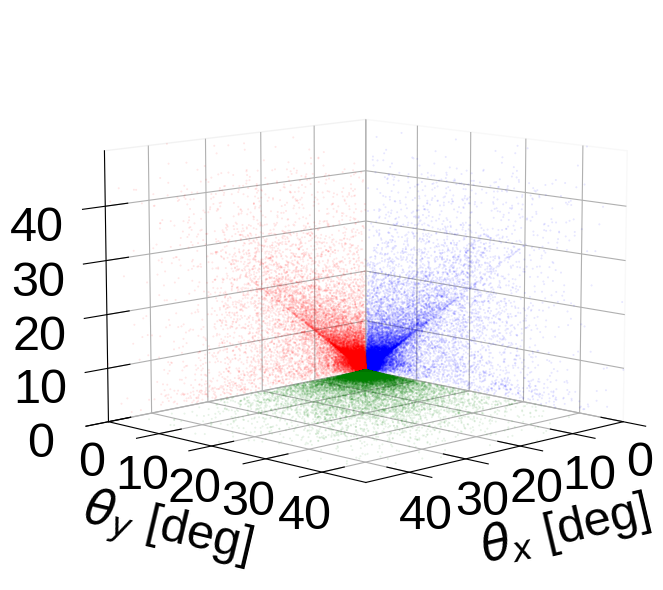

3d_scatter_with_projections.png


In [13]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Liberation Sans'

# 1. Generate Sample 3D Data (N, 3)
# Replace this with your actual (N, 3) data
N = 10000
# Example: Data following a correlated Gaussian distribution
# mu = [1, 2, 3]
# cov = [[1, 0.5, 0.1], [0.5, 1, -0.2], [0.1, -0.2, 1]]
# data_3d = np.random.multivariate_normal(mu, cov, N)
# X = data_3d[:, 0]
# Y = data_3d[:, 1]
# Z = data_3d[:, 2]



X = symmetry_reduced_x_axis_angle_misalignment_degree
Y = symmetry_reduced_y_axis_angle_misalignment_degree
Z = symmetry_reduced_z_axis_angle_misalignment_degree

# Define the boundaries for the projections
min_x, max_x = X.min(), X.max() + 0.1
min_y, max_y = Y.min(), Y.max() + 0.1
min_z, max_z = Z.min(), Z.max() + 0.1

# X = symmetry_reduced_x_axis_angle_misalignment_degree * np.pi / 180.
# Y = symmetry_reduced_y_axis_angle_misalignment_degree * np.pi / 180.
# Z = symmetry_reduced_z_axis_angle_misalignment_degree * np.pi / 180.

# min_x, max_x = X.min(), X.max()
# min_y, max_y = Y.min(), Y.max()
# min_z, max_z = Z.min(), Z.max()



# Define the location where the density maps will be projected

y_proj_loc = min_x  # yz plane projection (rectangle)
z_proj_loc = min_z  # xy plane projection (parallelogram/floor)
y_proj_loc_xz = min_y # xz plane projection (parallelogram/wall)


# 2. Setup the 3D Plot
fig = plt.figure(figsize=(8.5, 6))
ax = fig.add_subplot(111, projection='3d')


# xyz = np.vstack([X, Y, Z])
# density = gaussian_kde(xyz)(xyz)

# 3. 3D Scatter Plot (Component 1)
# ax.scatter(X, Y, Z, s=0.1, c=density, cmap='Purples', alpha=0.1, label='3D Points')
# ax.scatter(X, Y, Z, s=0.05, c=Z, cmap='Purples_r', alpha=0.05, label='3D Points')
# ax.scatter(X, Y, Z, s=0.1, c='#B027F5', alpha=0.1, label='3D Points')

# 4. Density Maps (Components 2, 3, 4)
# Density map for XY plane (Z constant)
# plot_density_map(ax, X, Y, loc=z_proj_loc, axis_type='z', cmap='Blues')

# # Density map for YZ plane (X constant - Rectangle)
# plot_density_map(ax, Y, Z, loc=y_proj_loc, axis_type='x', cmap='Greens')

# # Density map for XZ plane (Y constant)
# plot_density_map(ax, X, Z, loc=y_proj_loc_xz, axis_type='y', cmap='Reds')

# Projection on XY plane (floor)

plot_scatter_projection(ax, X, Y, loc=z_proj_loc, axis_type='z', color='green', alpha=0.1, s=0.2)

# Projection on YZ plane (side wall)
plot_scatter_projection(ax, Y, Z, loc=y_proj_loc, axis_type='x', color='blue', alpha=0.1, s=0.2)

# Projection on XZ plane (back wall)
plot_scatter_projection(ax, X, Z, loc=y_proj_loc_xz, axis_type='y', color='red', alpha=0.1, s=0.2)

# 5. Set Axes and Labels
ax.set_xlabel(r'$\theta_{x}$ [deg]', fontsize = 35, labelpad = 28)
ax.set_ylabel(r'$\theta_{y}$ [deg]', fontsize = 35, labelpad = 28)
ax.set_zlabel(r'$\theta_{z}$ [deg]', fontsize = 35, labelpad = 34)

# Set limits based on the min/max of the data plus the projection locations
ax.set_xlim(0.0, max_x)
ax.set_ylim(0.0, max_y)
ax.set_zlim(0.0, max_z)

# ax.invert_xaxis()
# ax.invert_yaxis()

ax.tick_params(axis='x', pad=0)
ax.tick_params(axis='y', pad=0)
ax.tick_params(axis='z', pad=0)

x_ticks = np.linspace(0, 40, 5)  # 6 ticks evenly spaced
y_ticks = np.linspace(0, 40, 5)
z_ticks = np.linspace(0, 40, 5)

ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)
ax.set_zticks(z_ticks)

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

ax.tick_params(axis='x', pad=5, width = 0.8, length = 20, labelsize=35)
ax.tick_params(axis='y', pad=5, width = 0.8, length = 20, labelsize=35)
ax.tick_params(axis='z', pad=20, width = 0.8, length = 20, labelsize=35)

# Actually, to make ticks longer, adjust these for each axis
ax.xaxis._axinfo['tick']['size'] = 35
ax.yaxis._axinfo['tick']['size'] = 35
ax.zaxis._axinfo['tick']['size'] = 35

ax.tick_params(axis='both', which='major', length=70) # Adjust 'length' as desired

# Adjust the viewing angle for better perspective
# ax.view_init(elev=20, azim=-60)
# ax.view_init(elev=35.26, azim=45)
ax.view_init(elev=10, azim=45)
# ax.view_init(elev=10, azim=10, roll = 2)
# ax.view_init(elev=13, azim=6, roll = 1.4)

for axis in ['x', 'y', 'z']:
    ax.tick_params(axis=axis, length=35)  # affects label padding
for axis in ['z']:
    ax.tick_params(axis=axis, length=60)  # affects label padding
ax.xaxis._axinfo['tick']['inward_factor'] = 1
ax.xaxis._axinfo['tick']['outward_factor'] = 1
ax.yaxis._axinfo['tick']['inward_factor'] = 1
ax.yaxis._axinfo['tick']['outward_factor'] = 1
ax.zaxis._axinfo['tick']['inward_factor'] = 1
ax.zaxis._axinfo['tick']['outward_factor'] = 1

# ax.view_init(elev=215.26, azim=-45)
# plt.title('3D Scatter Plot with 2D Projections')
fig.tight_layout()

plt.savefig(panel_f_directory_path + 'symmetry_reduced_directions_x_y_z_test_set.pdf', 
            bbox_inches='tight', 
            dpi=300)
plt.savefig(panel_f_directory_path + 'symmetry_reduced_directions_x_y_z_test_set.png', 
            bbox_inches='tight', 
            dpi=300)
plt.show()
print('3d_scatter_with_projections.png')

In [14]:
grid_points = 350

lower_bound = 0.65
upper_bound = 1.0

grid = np.linspace(lower_bound, upper_bound, grid_points)
G0, G1 = np.meshgrid(grid, grid)

xy = np.vstack([symmetry_reduced_x_axis_cosine_angle, symmetry_reduced_y_axis_cosine_angle])
kde_xy = gaussian_kde(xy)


xz = np.vstack([symmetry_reduced_x_axis_cosine_angle, symmetry_reduced_z_axis_cosine_angle])
kde_xz = gaussian_kde(xz)

# Evaluate on a periodic grid
Z_0 = kde_xy(np.vstack([G0.ravel(), G1.ravel()])).reshape(G0.shape)
Y_0 = kde_xz(np.vstack([G0.ravel(), G1.ravel()])).reshape(G0.shape)



In [14]:
np.max(Z_0), np.max(Y_0)

(np.float64(24270.93166669315), np.float64(20315.468484709414))

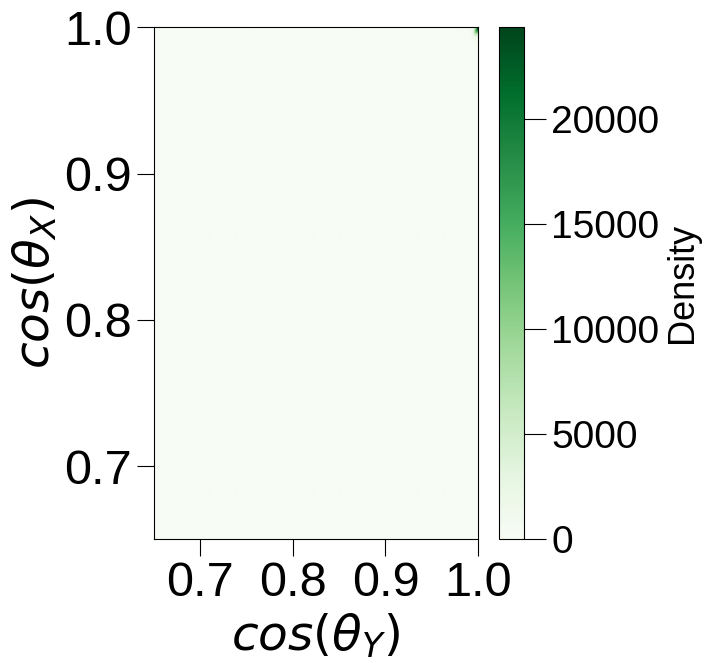

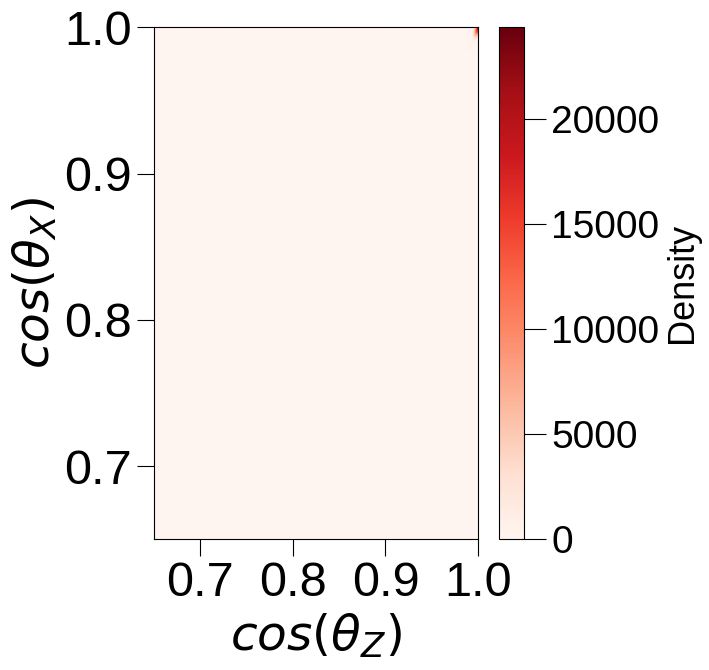

In [16]:
max_density_val = max(np.max(Z_0), np.max(Y_0))

# --- Figure 1: X-Y density heatmap ---
fig_xy, ax_xy = plt.subplots(figsize=(7, 6.8))
im_xy = ax_xy.imshow(Z_0, origin='lower', 
                     extent=[lower_bound, upper_bound, lower_bound, upper_bound],
                     cmap='Greens', aspect='auto',
                    vmin = 0.0, vmax = 24372)
cbar_xy = fig_xy.colorbar(im_xy, ax=ax_xy, label='Density', ticks=[0.0, 5000, 10000, 15000, 20000])

cbar_xy.ax.yaxis.label.set_size(26)
# Increase tick size and length
cbar_xy.ax.tick_params(labelsize=28, length=16, width=0.8)

ax_xy.set_xlabel(r'$cos(\theta_{Y})$', fontsize = 35)
ax_xy.set_ylabel(r'$cos(\theta_{X})$', fontsize = 35)
# ax_xy.set_title('X-Y Density Heatmap', fontsize = 28)
ax_xy.set_yticks([0.7, 0.8, 0.9, 1.0])
ax_xy.set_xticks([0.7, 0.8, 0.9, 1.0])
ax_xy.tick_params(axis='x', direction='out', length=12, width=0.8, color='k', labelsize=35)
ax_xy.tick_params(axis='y', direction='out', length=12, width=0.8, color='k', labelsize=35)
fig_xy.tight_layout()
plt.savefig(panel_g_directory_path + 'cosine_theta_X_Y_heat_map_test_set.pdf', bbox_inches='tight', dpi=300)
plt.savefig(panel_g_directory_path + 'cosine_theta_X_Y_heat_map_test_set.png', bbox_inches='tight', dpi=300)
plt.show()

# --- Figure 2: X-Z density heatmap ---
fig_xz, ax_xz = plt.subplots(figsize=(7, 6.8))
im_xz = ax_xz.imshow(Y_0, origin='lower', 
                     extent=[lower_bound, upper_bound, lower_bound, upper_bound],
                     cmap='Reds', aspect='auto',
                    vmin = 0.0, vmax = 24372)
cbar_xz = fig_xz.colorbar(im_xz, ax=ax_xz, label='Density', ticks=[0.0, 5000, 10000, 15000, 20000])
cbar_xz.ax.yaxis.label.set_size(26)
# Increase tick size and length
cbar_xz.ax.tick_params(labelsize=28, length=16, width=0.8)
ax_xz.set_xlabel(r'$cos(\theta_{Z})$', fontsize = 35)
ax_xz.set_ylabel(r'$cos(\theta_{X})$', fontsize = 35)
# ax_xz.set_title('X-Z Density Heatmap')
ax_xz.set_yticks([0.7, 0.8, 0.9, 1.0])
ax_xz.set_xticks([0.7, 0.8, 0.9, 1.0])
ax_xz.tick_params(axis='x', direction='out', length=12, width=0.8, color='k', labelsize=35)
ax_xz.tick_params(axis='y', direction='out', length=12, width=0.8, color='k', labelsize=35)
fig_xz.tight_layout()
plt.savefig(panel_g_directory_path + 'cosine_theta_X_Z_heat_map_test_set.pdf', bbox_inches='tight', dpi=300)
plt.savefig(panel_g_directory_path + 'cosine_theta_X_Z_heat_map_test_set.png', bbox_inches='tight', dpi=300)
plt.show()

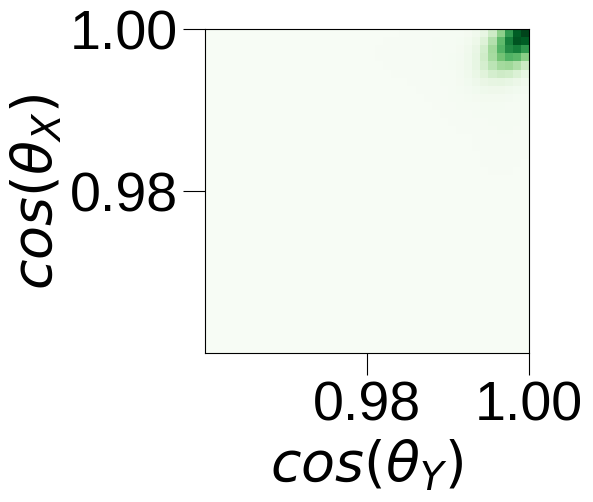

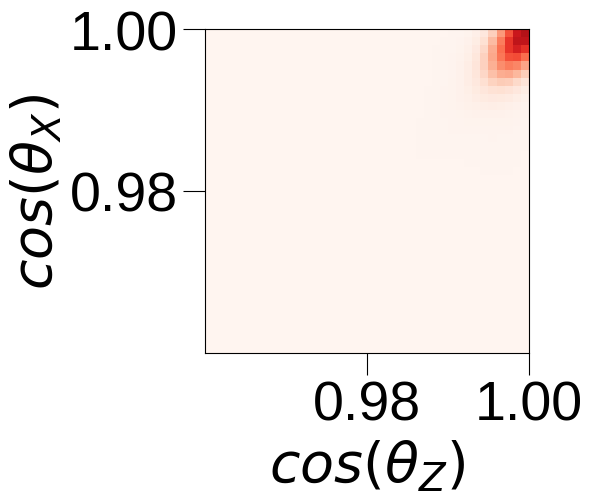

In [17]:
# --- Figure 1: X-Y density heatmap ---
fig_xy, ax_xy = plt.subplots(figsize=(6, 6))
im_xy = ax_xy.imshow(Z_0, origin='lower', 
                     extent=[lower_bound, upper_bound, lower_bound, upper_bound],
                     cmap='Greens',
                    vmin = 0.0, vmax = max_density_val)
# fig_xy.colorbar(im_xy, ax=ax_xy, label='Density')
ax_xy.set_xlabel(r'$cos(\theta_{Y})$', fontsize = 40)
ax_xy.set_ylabel(r'$cos(\theta_{X})$', fontsize = 40)
# ax_xy.set_title('X-Y Density Heatmap', fontsize = 28)
ax_xy.set_xlim([0.96, 1.0])
ax_xy.set_ylim([0.96, 1.0])
ax_xy.set_yticks([0.98, 1.0])
ax_xy.set_xticks([0.98, 1.0])
ax_xy.tick_params(axis='x', direction='out', length=16, width=0.8, color='k', labelsize=40)
ax_xy.tick_params(axis='y', direction='out', length=16, width=0.8, color='k', labelsize=40)
fig_xy.tight_layout()
plt.savefig(panel_g_directory_path + 'cosine_theta_X_Y_heat_map_zoomed_test_set.pdf', bbox_inches='tight', dpi=300)
plt.savefig(panel_g_directory_path + 'cosine_theta_X_Y_heat_map_zoomed_test_set.png', bbox_inches='tight', dpi=300)
plt.show()

# --- Figure 2: X-Z density heatmap ---
fig_xz, ax_xz = plt.subplots(figsize=(6, 6))
im_xz = ax_xz.imshow(Y_0, origin='lower', 
                     extent=[lower_bound, upper_bound, lower_bound, upper_bound],
                     cmap='Reds',
                    vmin = 0.0, vmax = max_density_val)
# fig_xz.colorbar(im_xz, ax=ax_xz, label='Density')
ax_xz.set_xlabel(r'$cos(\theta_{Z})$', fontsize = 40)
ax_xz.set_ylabel(r'$cos(\theta_{X})$', fontsize = 40)
ax_xz.set_xlim([0.96, 1.0])
ax_xz.set_ylim([0.96, 1.0])
ax_xz.set_yticks([0.98, 1.0])
ax_xz.set_xticks([0.98, 1.0])
ax_xz.tick_params(axis='x', direction='out', length=16, width=0.8, color='k', labelsize=40)
ax_xz.tick_params(axis='y', direction='out', length=16, width=0.8, color='k', labelsize=40)
fig_xz.tight_layout()
plt.savefig(panel_g_directory_path + 'cosine_theta_X_Z_heat_map_zoomed_test_set.pdf', bbox_inches='tight', dpi=300)
plt.savefig(panel_g_directory_path + 'cosine_theta_X_Z_heat_map_zoomed_test_set.png', bbox_inches='tight', dpi=300)
plt.show()

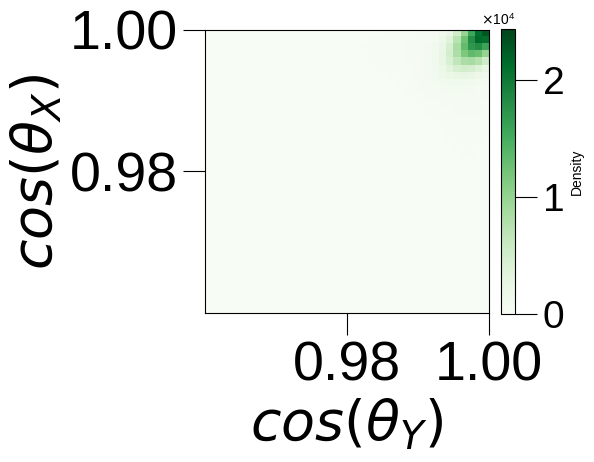

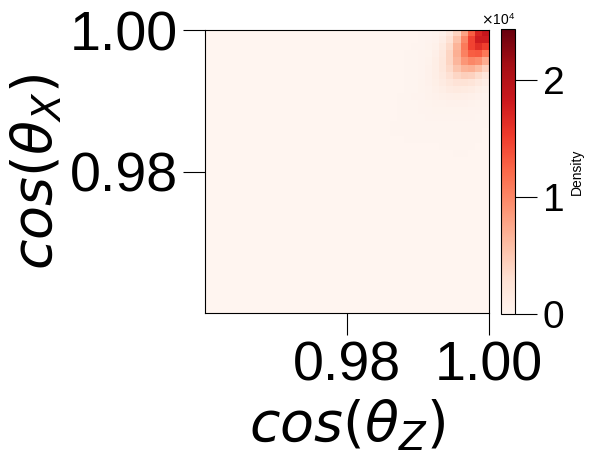

In [18]:
from matplotlib.ticker import ScalarFormatter

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((1, 4))   # force 10^4

# --- Figure 1: X-Y density heatmap ---
fig_xy, ax_xy = plt.subplots(figsize=(6, 6))
im_xy = ax_xy.imshow(Z_0, origin='lower', 
                     extent=[lower_bound, upper_bound, lower_bound, upper_bound],
                     cmap='Greens',
                    vmin = 0.0, vmax = 24372)


cbar_xy = fig_xy.colorbar(im_xy, ax=ax_xy, label='Density', ticks=[0.0, 10000,  20000],
                         fraction=0.046,  # thickness
                            pad=0.04,        # gap to axes
                            shrink=0.75)

# cbar_xy.ax.yaxis.label.set_size(26)
# Increase tick size and length
cbar_xy.ax.tick_params(labelsize=28, length=16, width=0.8)

cbar_xy.ax.yaxis.set_major_formatter(formatter)
# cbar_xy.update_ticks()

ax_xy.set_xlabel(r'$cos(\theta_{Y})$', fontsize = 40)
ax_xy.set_ylabel(r'$cos(\theta_{X})$', fontsize = 40)
# ax_xy.set_title('X-Y Density Heatmap', fontsize = 28)
ax_xy.set_xlim([0.96, 1.0])
ax_xy.set_ylim([0.96, 1.0])
ax_xy.set_yticks([0.98, 1.0])
ax_xy.set_xticks([0.98, 1.0])
ax_xy.tick_params(axis='x', direction='out', length=16, width=0.8, color='k', labelsize=40)
ax_xy.tick_params(axis='y', direction='out', length=16, width=0.8, color='k', labelsize=40)
fig_xy.tight_layout()
plt.savefig(panel_g_directory_path + 'cosine_theta_X_Y_heat_map_zoomed_test_set_with_cbar.pdf', bbox_inches='tight', dpi=300)
plt.savefig(panel_g_directory_path + 'cosine_theta_X_Y_heat_map_zoomed_test_set_with_cbar.png', bbox_inches='tight', dpi=300)
plt.show()

# --- Figure 2: X-Z density heatmap ---
fig_xz, ax_xz = plt.subplots(figsize=(6, 6))
im_xz = ax_xz.imshow(Y_0, origin='lower', 
                     extent=[lower_bound, upper_bound, lower_bound, upper_bound],
                     cmap='Reds',
                    vmin = 0.0, vmax = 24372)

cbar_xz = fig_xz.colorbar(im_xz, ax=ax_xz, label='Density', ticks=[0.0, 10000,  20000],
                         fraction=0.046,  # thickness
                            pad=0.04,        # gap to axes
                            shrink=0.75)

cbar_xz.ax.tick_params(labelsize=28, length=16, width=0.8)
cbar_xz.ax.yaxis.set_major_formatter(formatter)
# fig_xz.colorbar(im_xz, ax=ax_xz, label='Density')
ax_xz.set_xlabel(r'$cos(\theta_{Z})$', fontsize = 40)
ax_xz.set_ylabel(r'$cos(\theta_{X})$', fontsize = 40)
ax_xz.set_xlim([0.96, 1.0])
ax_xz.set_ylim([0.96, 1.0])
ax_xz.set_yticks([0.98, 1.0])
ax_xz.set_xticks([0.98, 1.0])
ax_xz.tick_params(axis='x', direction='out', length=16, width=0.8, color='k', labelsize=40)
ax_xz.tick_params(axis='y', direction='out', length=16, width=0.8, color='k', labelsize=40)
fig_xz.tight_layout()
plt.savefig(panel_g_directory_path + 'cosine_theta_X_Z_heat_map_zoomed_test_set_with_cbar.pdf', bbox_inches='tight', dpi=300)
plt.savefig(panel_g_directory_path + 'cosine_theta_X_Z_heat_map_zoomed_test_set_with_cbar.png', bbox_inches='tight', dpi=300)
plt.show()

In [11]:
new_orientation.family, new_orientation.matrix

(array([[[0.3003881 , 0.16947812, 0.46329068],
         [0.41581975, 0.5990171 , 0.48416551],
         [0.85840604, 0.78259548, 0.74225704]]]),
 array([[[ 0.3003881 ,  0.5990171 ,  0.74225704],
         [-0.41581975,  0.78259548, -0.46329068],
         [-0.85840604, -0.16947812,  0.48416551]]]))

# For test set data points where geodesic loss is higher than threshold (0.6), find data points resulting good prediction though loss value appears high

In [134]:
len(index_of_DP_with_high_geodesic_loss_val), corresponding_geodesic_distances

(9530,
 array([0.67663765, 0.91220325, 0.96645164, ..., 1.0438731 , 0.78577405,
        0.86219555], dtype=float32))

In [16]:
py4DSTEM_CorrValue_for_predi = []
py4DSTEM_CorrValue_for_random = []

assignment_costs = []
assignment_costs_random = []
randomly_sampled_rotation_matrices = []
reference_check_geo_dist = []
for index in index_of_DP_with_high_geodesic_loss_val:
    
    rotation_label = test_set_label_rotation_matrices[index]
    rotation_predi = test_set_predi_rotation_matrices[index]
    
    geodesic_distance = test_set_geodesic_distances_trained[index]
    reference_check_geo_dist.append(geodesic_distance)
    
    rotation_random = sample_rotation_at_rand_geodesic_distance(rotation_label, geodesic_distance)
    
    randomly_sampled_rotation_matrices.append(rotation_random)
    
    bragg_peaks_label = crystal.generate_diffraction_pattern(
                                        orientation_matrix = rotation_label,
                                        ind_orientation=0,
                                        sigma_excitation_error = excitation_error)
    XYI_label = np.stack((bragg_peaks_label.data['qx'], bragg_peaks_label.data['qy'], bragg_peaks_label.data['intensity'])).T


    #### PREDICTION

    crystal_for_cor = py4DSTEM.process.diffraction.Crystal.from_CIF(data_path + "Cu_fcc.cif")
    crystal_for_cor.setup_diffraction(accelerating_voltage)
    crystal_for_cor.calculate_structure_factors(k_max)
    
    idx_of_zone_axis_for_replacement, is_input_rotation_matrix_inverted_wrt_canonical = orientation_plan_init_for_single_pattern(
        crystal_for_cor,
        rotation_predi,
        angle_step_zone_axis = 2,
        angle_step_in_plane = 2,
        accel_voltage = 300e3,
        zone_axis_range='auto',
        progress_bar = False,
    )
    
    predicted_orientation_object, orientation_predi_corr_value = measure_sparseCorr_of_single_pattern(
                        crystal = crystal_for_cor,
                        bragg_peaks = bragg_peaks_label,
                        inversion_symmetry = is_input_rotation_matrix_inverted_wrt_canonical,
                           )

    py4DSTEM_CorrValue_for_predi.append(orientation_predi_corr_value)

    del crystal_for_cor, idx_of_zone_axis_for_replacement, is_input_rotation_matrix_inverted_wrt_canonical, predicted_orientation_object, orientation_predi_corr_value  

    bragg_peaks_predi = crystal.generate_diffraction_pattern(
                                        orientation_matrix = rotation_predi,
                                        ind_orientation=0,
                                        sigma_excitation_error = excitation_error)
    
    XYI_predi = np.stack((bragg_peaks_predi.data['qx'], bragg_peaks_predi.data['qy'], bragg_peaks_predi.data['intensity'])).T

    # fig, ax = py4DSTEM.process.diffraction.plot_diffraction_pattern(
    #         bragg_peaks_label,
    #         scale_markers=1000,
    #         # plot_range_kx_ky=range_plot,
    #         min_marker_size=3,
    #         figsize = (5,5),
    #         shift_labels = 0.2,
    #         add_labels = False,
    #         returnfig = True,
    # )
    # plt.show()

    # fig, ax = py4DSTEM.process.diffraction.plot_diffraction_pattern(
    #         bragg_peaks_predi,
    #         scale_markers=1000,
    #         # plot_range_kx_ky=range_plot,
    #         min_marker_size=3,
    #         figsize = (5,5),
    #         shift_labels = 0.2,
    #         add_labels = False,
    #         returnfig = True,
    # )
    # plt.show()

    #### RANDOM

    crystal_for_cor = py4DSTEM.process.diffraction.Crystal.from_CIF(data_path + "Cu_fcc.cif")
    crystal_for_cor.setup_diffraction(accelerating_voltage)
    crystal_for_cor.calculate_structure_factors(k_max)
    
    idx_of_zone_axis_for_replacement, is_input_rotation_matrix_inverted_wrt_canonical = orientation_plan_init_for_single_pattern(
        crystal_for_cor,
        rotation_random,
        angle_step_zone_axis = 2,
        angle_step_in_plane = 2,
        accel_voltage = 300e3,
        zone_axis_range='auto',
        progress_bar = False,
    )
    
    predicted_orientation_object, orientation_random_corr_value = measure_sparseCorr_of_single_pattern(
                        crystal = crystal_for_cor,
                        bragg_peaks = bragg_peaks_label,
                        inversion_symmetry = is_input_rotation_matrix_inverted_wrt_canonical,
                           )

    py4DSTEM_CorrValue_for_random.append(orientation_random_corr_value)

    del crystal_for_cor, idx_of_zone_axis_for_replacement, is_input_rotation_matrix_inverted_wrt_canonical, predicted_orientation_object, orientation_random_corr_value

    bragg_peaks_random = crystal.generate_diffraction_pattern(
                                        orientation_matrix = rotation_random,
                                        ind_orientation=0,
                                        sigma_excitation_error = excitation_error)
    
    XYI_random = np.stack((bragg_peaks_random.data['qx'], bragg_peaks_random.data['qy'], bragg_peaks_random.data['intensity'])).T

    assignment_costs.append(assignment_cost_pairwise_distance(XYI_label, XYI_predi))
    assignment_costs_random.append(assignment_cost_pairwise_distance(XYI_label, XYI_random))


reference_check_geo_dist = np.array(reference_check_geo_dist)
assert np.sum(np.abs(reference_check_geo_dist - corresponding_geodesic_distances)) < 1e-8, "There is an error in random sampling of SO rotation from geodesic distance; the geodesic distance are not the same."
assert reference_check_geo_dist.shape[0] == corresponding_geodesic_distances.shape[0], "There is an error in random sampling of SO rotation from geodesic distance; the numbers of the geodesic distance used in sampling does not match the numbers of original geodesic distances."


assignment_costs = np.array(assignment_costs)
assignment_costs_random = np.array(assignment_costs_random)


randomly_sampled_rotation_matrices = np.array(randomly_sampled_rotation_matrices)
py4DSTEM_CorrValue_for_predi = np.array(py4DSTEM_CorrValue_for_predi)
py4DSTEM_CorrValue_for_random = np.array(py4DSTEM_CorrValue_for_random)


np.save(panel_e_directory_path + "prediction_from_test_data_above_threshold%3.2f_py4DSTEM_corr_value.npy"%(geodesic_distance_threshold), py4DSTEM_CorrValue_for_predi)
np.save(panel_e_directory_path + "random_sampling_for_data_above_threshold%3.2f_py4DSTEM_corr_value.npy"%(geodesic_distance_threshold), py4DSTEM_CorrValue_for_random)

np.save(panel_e_directory_path + "prediction_from_test_data_above_threshold%3.2f_weighted_linear_sum_assignment_cost.npy"%(geodesic_distance_threshold), assignment_costs)
np.save(panel_e_directory_path + "random_sampling_for_data_above_threshold%3.2f_weighted_linear_sum_assignment_cost.npy"%(geodesic_distance_threshold), assignment_costs_random)

np.save(panel_e_directory_path + "randomly_sampled_rotation_matrices.npy", randomly_sampled_rotation_matrices)


In [18]:
len(randomly_sampled_rotation_matrices), len(test_set_label_rotation_matrices), len(py4DSTEM_CorrValue_for_predi)

(9041, 65536, 9041)

In [24]:
np.max(py4DSTEM_CorrValue_for_predi), np.min(py4DSTEM_CorrValue_for_predi)

(np.float64(2.031319780649571), np.float64(0.0))

In [25]:
np.max(py4DSTEM_CorrValue_for_random), np.min(py4DSTEM_CorrValue_for_random)

(np.float64(0.8515238787894192), np.float64(0.0))

In [21]:
for i in range(len(assignment_costs)):
    if assignment_costs[i] < 1e-4:
        if corresponding_geodesic_distances[i] > 0.9:
            print("")
            print("##########################################################")
            print("i",i)
            print("assignment_costs[i]", assignment_costs[i])
            print("corresponding_geodesic_distances[i]", corresponding_geodesic_distances[i])


##########################################################
i 9
assignment_costs[i] 7.947807598428133e-05
corresponding_geodesic_distances[i] 1.0408632

##########################################################
i 29
assignment_costs[i] 5.477420586683687e-05
corresponding_geodesic_distances[i] 1.0401037

##########################################################
i 77
assignment_costs[i] 4.263742407447501e-05
corresponding_geodesic_distances[i] 1.041093

##########################################################
i 175
assignment_costs[i] 8.507802340454874e-05
corresponding_geodesic_distances[i] 1.0375803

##########################################################
i 389
assignment_costs[i] 1.0494127183378277e-05
corresponding_geodesic_distances[i] 1.0423362

##########################################################
i 426
assignment_costs[i] 8.762740949749424e-05
corresponding_geodesic_distances[i] 1.0245175

##########################################################
i 436
assignment_cos

rotation_label
 [[ 0.88474183 -0.20958194  0.41630193]
 [ 0.3907101   0.82050044 -0.41728246]
 [-0.25412105  0.53184062  0.80781684]] 

rotation_predi
 [[ 0.38611472  0.8332803   0.3956762 ]
 [-0.88748896  0.21859874  0.405682  ]
 [ 0.25155246 -0.507798    0.8239313 ]] 

rotation_random
 [[ 0.48580625  0.60817725  0.62778392]
 [-0.31557589  0.7918297  -0.52289343]
 [-0.81510985  0.05591141  0.57660194]] 

np.linalg.det(rotation_label) 0.9999999999999998
np.linalg.det(rotation_predi) 1.0000002
np.linalg.det(rotation_random) 0.9999999230571351


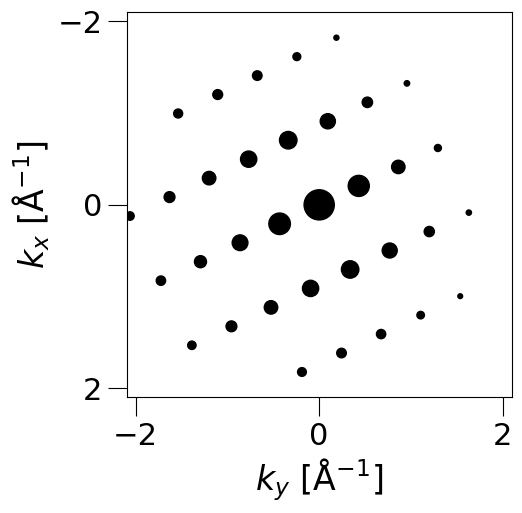

7.947807598428133e-05
test_set_geodesic_distances_trained[count] 1.0408632


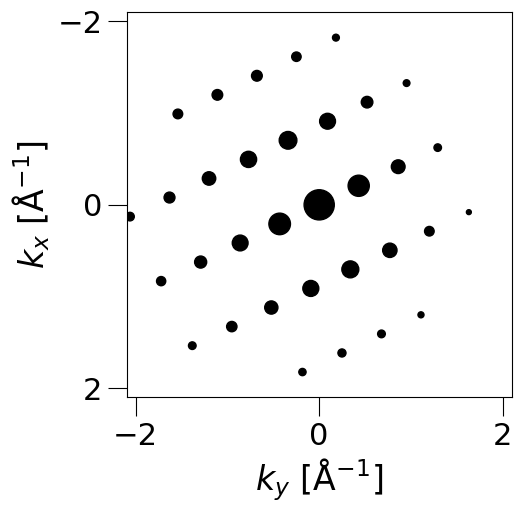

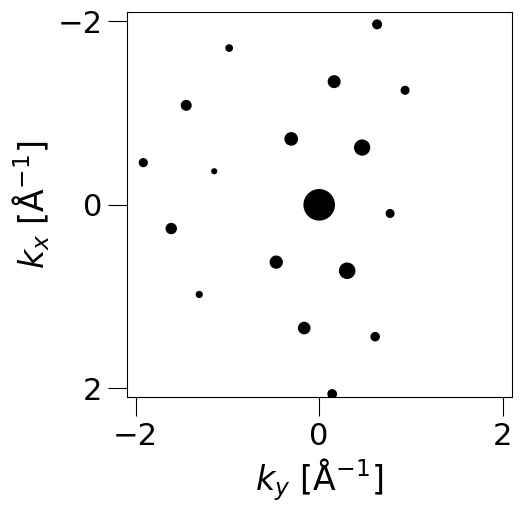

In [23]:


count = 0
for count, index in enumerate(index_of_DP_with_high_geodesic_loss_val):
    

    if count == 9:

        rotation_label = test_set_label_rotation_matrices[index]
        rotation_predi = test_set_predi_rotation_matrices[index]
        # rotation_random = sample_rotation_at_rand_geodesic_distance(rotation_label, test_set_geodesic_distances_trained[index])
        rotation_random = randomly_sampled_rotation_matrices[count]
        print("rotation_label\n", rotation_label, "\n")
        print("rotation_predi\n", rotation_predi, "\n")
        print("rotation_random\n", rotation_random, "\n")
        print("np.linalg.det(rotation_label)", np.linalg.det(rotation_label))
        print("np.linalg.det(rotation_predi)", np.linalg.det(rotation_predi))
        print("np.linalg.det(rotation_random)", np.linalg.det(rotation_random))
    
        bragg_peaks_fit = crystal.generate_diffraction_pattern(
                                            orientation_matrix = rotation_label,
                                            ind_orientation=0,
                                            sigma_excitation_error=0.02)
        fig, ax = py4DSTEM.process.diffraction.plot_diffraction_pattern(
                bragg_peaks_fit,
                scale_markers=1000,
                plot_range_kx_ky=range_plot,
                min_marker_size=3,
                figsize = (5,5),
                shift_labels = 0.2,
                add_labels = False,
                returnfig = True,
        )
        fig.savefig(panel_e_directory_path + 'kim_sim_from_ground_truth_test_set_id_%d.pdf'%(index), bbox_inches='tight', dpi=300)
        plt.show()

        
        XYI_label = np.copy(np.stack((bragg_peaks_fit.data['qx'], bragg_peaks_fit.data['qy'], bragg_peaks_fit.data['intensity'])).T)
    
        bragg_peaks_fit = crystal.generate_diffraction_pattern(
                                            orientation_matrix = rotation_predi,
                                            ind_orientation=0,
                                            sigma_excitation_error=0.02)
        XYI_predi = np.stack((bragg_peaks_fit.data['qx'], bragg_peaks_fit.data['qy'], bragg_peaks_fit.data['intensity'])).T
    
        print(assignment_cost_pairwise_distance(XYI_label, XYI_predi))
        print("test_set_geodesic_distances_trained[count]", test_set_geodesic_distances_trained[index])

        fig, ax = py4DSTEM.process.diffraction.plot_diffraction_pattern(
                bragg_peaks_fit,
                scale_markers=1000,
                plot_range_kx_ky=range_plot,
                min_marker_size=3,
                figsize = (5,5),
                shift_labels = 0.2,
                add_labels = False,
                returnfig = True,
        )
        fig.savefig(panel_e_directory_path + 'kim_sim_from_prediction_truth_test_set_id_%d.pdf'%(index), bbox_inches='tight', dpi=300)
        plt.show()

        bragg_peaks_fit = crystal.generate_diffraction_pattern(
                                        orientation_matrix = rotation_random,
                                        ind_orientation=0,
                                        sigma_excitation_error=0.02)

        fig, ax = py4DSTEM.process.diffraction.plot_diffraction_pattern(
                bragg_peaks_fit,
                scale_markers=1000,
                plot_range_kx_ky=range_plot,
                min_marker_size=3,
                figsize = (5,5),
                shift_labels = 0.2,
                add_labels = False,
                returnfig = True,
        )
        fig.savefig(panel_e_directory_path + 'kim_sim_from_randomly_sampled_rotation_id_%d.pdf'%(index), bbox_inches='tight', dpi=300)
        plt.show()
        



Peak location_trained: 0.7483483483483484
Peak location_untrained: 0.002102102102102102
predi: 50th percentile (CDF=0.50) location: 0.4981981981981982
randn: 75th percentile (CDF=0.75) location: 0.3825825825825826


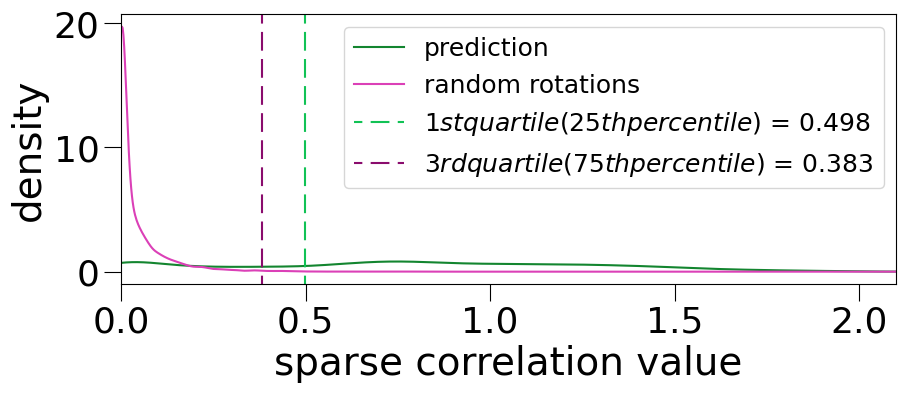

In [26]:

# valid_set_geodesic_distances_trained = np.load("./geodesic_distances_trained_valid.npy")
# valid_set_geodesic_distances_untrained = np.load("./geodesic_distances_untrained_valid.npy")


# Create KDE
lower_bound = 0.0
upper_bound = 2.1

# Evaluate KDE on a fine grid
kde_pred_py4DSTEM_CorrValue = gaussian_kde(py4DSTEM_CorrValue_for_predi)
kde_rand_py4DSTEM_CorrValue = gaussian_kde(py4DSTEM_CorrValue_for_random)

x_grid = np.linspace(lower_bound, upper_bound, 1000)
kde_values_pred_py4DSTEM_CorrValue = kde_pred_py4DSTEM_CorrValue(x_grid)
kde_values_rand_py4DSTEM_CorrValue = kde_rand_py4DSTEM_CorrValue(x_grid)

# Find the peak (location of maximum density)
peak_location_pred = x_grid[np.argmax(kde_values_pred_py4DSTEM_CorrValue)]
print("Peak location_trained:", peak_location_pred)

peak_location_rand = x_grid[np.argmax(kde_values_rand_py4DSTEM_CorrValue)]
print("Peak location_untrained:", peak_location_rand)

# Compute CDF by cumulative sum
dx = x_grid[1] - x_grid[0]  # spacing
cdf_predi = np.cumsum(kde_values_pred_py4DSTEM_CorrValue) * dx  # approximate CDF
cdf_randn = np.cumsum(kde_values_rand_py4DSTEM_CorrValue) * dx  # approximate CDF

# Find x where CDF = 0.8
predi_50_percentile_median = x_grid[np.searchsorted(cdf_predi, 0.25)]
randn_75_percentile_median = x_grid[np.searchsorted(cdf_randn, 0.75)]
print("predi: 50th percentile (CDF=0.50) location:", predi_50_percentile_median)
print("randn: 75th percentile (CDF=0.75) location:", randn_75_percentile_median)

fig, ax = plt.subplots(1, 1, figsize=(10, 3.5))
ax.plot(x_grid, kde_values_pred_py4DSTEM_CorrValue, label="prediction", color = "#13852F", linewidth = 1.5)
ax.plot(x_grid, kde_values_rand_py4DSTEM_CorrValue, label="random rotations", color = "#DB40B7", linewidth = 1.5)
ax.axvline(predi_50_percentile_median, color="#11C255", linestyle=(5, (9, 4)), label=r"$1st quartile (25th percentile) $" + f" = {predi_50_percentile_median:4.3f}")
ax.axvline(randn_75_percentile_median, color="#8A0C6D", linestyle=(5, (9, 4)), label=r"$3rd quartile (75th percentile) $" + f" = {randn_75_percentile_median:4.3f}")
# ax.axvline(peak_location_rand, color="#8A0C6D", linestyle="solid", label=r"$corr$" + f" = {peak_location_rand:4.3f}")
# ax.fill_between(x_grid, kde_values_trained, alpha=0.3)
# ax.fill_between(x_grid, kde_values_untrained, alpha=0.3)
ax.legend(fontsize = 18)
ax.set_xlim([0.0, upper_bound])
# ax.set_xscale('log')

# ax.set_ylim([-0.00000001,2.4])
# ax.set_yticks([0.0, 50, 100])
ax.set_xlabel(r"sparse correlation value", fontsize = 28)
ax.set_ylabel(r"density", fontsize = 28)
ax.tick_params(axis='x', direction='out', length=12, width=0.8, color='k', labelsize=26)
ax.tick_params(axis='y', direction='out', length=12, width=0.8, color='k', labelsize=26)
# plt.savefig(panel_e_directory_path + 'new_0102_2026_sparse_correlation_value_comparison.pdf', bbox_inches='tight', dpi=300)
plt.show()

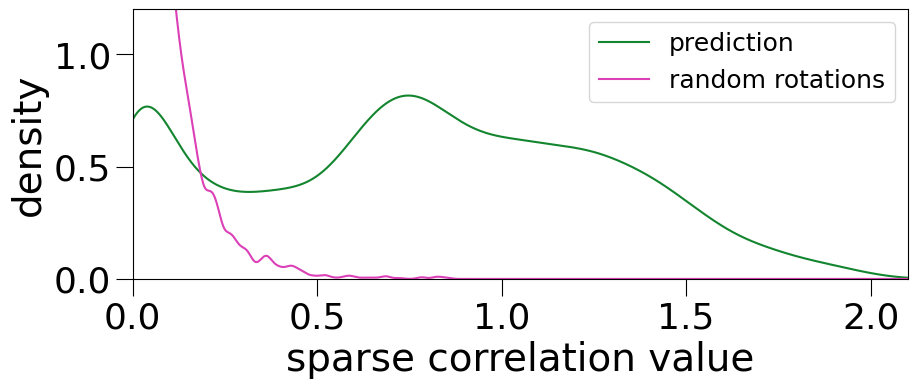

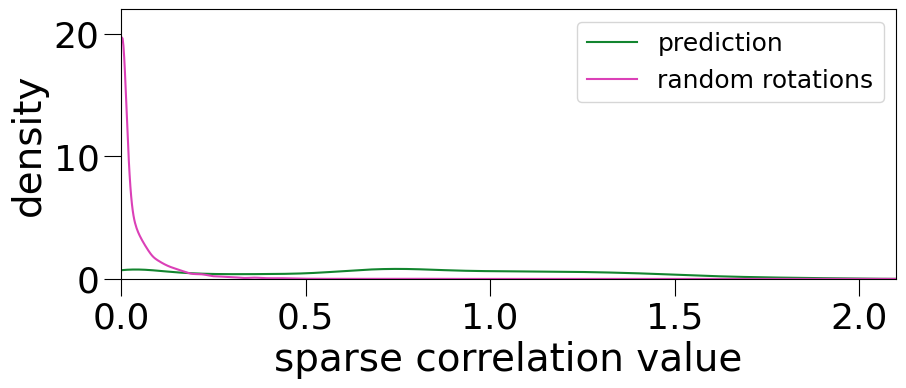

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(10, 3.5))
ax.plot(x_grid, kde_values_pred_py4DSTEM_CorrValue, label="prediction", color = "#13852F", linewidth = 1.5)
ax.plot(x_grid, kde_values_rand_py4DSTEM_CorrValue, label="random rotations", color = "#DB40B7", linewidth = 1.5)
ax.legend(fontsize = 18)
ax.set_xlim([0.0, upper_bound])
ax.set_ylim([-0.00000001,1.2])
ax.set_xlabel(r"sparse correlation value", fontsize = 28)
ax.set_ylabel(r"density", fontsize = 28)
ax.tick_params(axis='x', direction='out', length=12, width=0.8, color='k', labelsize=26)
ax.tick_params(axis='y', direction='out', length=12, width=0.8, color='k', labelsize=26)
plt.savefig(panel_e_directory_path + 'new_0102_2026_sparse_correlation_value_comparison_magnified.pdf', bbox_inches='tight', dpi=300)
plt.show()


fig, ax = plt.subplots(1, 1, figsize=(10, 3.5))
ax.plot(x_grid, kde_values_pred_py4DSTEM_CorrValue, label="prediction", color = "#13852F", linewidth = 1.5)
ax.plot(x_grid, kde_values_rand_py4DSTEM_CorrValue, label="random rotations", color = "#DB40B7", linewidth = 1.5)
ax.legend(fontsize = 18)
ax.set_xlim([0.0, upper_bound])
ax.set_ylim([-0.00000001,22])
ax.set_xlabel(r"sparse correlation value", fontsize = 28)
ax.set_ylabel(r"density", fontsize = 28)
ax.tick_params(axis='x', direction='out', length=12, width=0.8, color='k', labelsize=26)
ax.tick_params(axis='y', direction='out', length=12, width=0.8, color='k', labelsize=26)
plt.savefig(panel_e_directory_path + 'new_0102_2026_sparse_correlation_value_comparison.pdf', bbox_inches='tight', dpi=300)
plt.show()

Peak location_trained: 0.0011331850495339805
Peak location_untrained: 0.027312496712911534


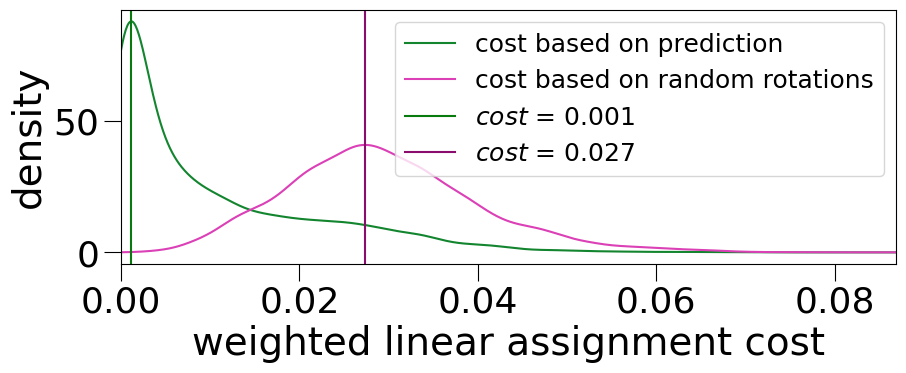

In [31]:

# valid_set_geodesic_distances_trained = np.load("./geodesic_distances_trained_valid.npy")
# valid_set_geodesic_distances_untrained = np.load("./geodesic_distances_untrained_valid.npy")


# Create KDE
lower_bound = 2.517103939601066e-06
upper_bound = 0.08689

# Evaluate KDE on a fine grid
kde_pred_linAssignCost = gaussian_kde(assignment_costs)
kde_rand_linAssignCost = gaussian_kde(assignment_costs_random)

x_grid = np.linspace(lower_bound, upper_bound, 1000)
kde_values_pred_linAssignCost = kde_pred_linAssignCost(x_grid)
kde_values_rand_linAssignCost = kde_rand_linAssignCost(x_grid)

# Find the peak (location of maximum density)
peak_location_pred = x_grid[np.argmax(kde_values_pred_linAssignCost)]
print("Peak location_trained:", peak_location_pred)

peak_location_rand = x_grid[np.argmax(kde_values_rand_linAssignCost)]
print("Peak location_untrained:", peak_location_rand)

# Optional: plot

fig, ax = plt.subplots(1, 1, figsize=(10, 3.3))
ax.plot(x_grid, kde_values_pred_linAssignCost, label="cost based on prediction", color = "#13852F", linewidth = 1.5)
ax.plot(x_grid, kde_values_rand_linAssignCost, label="cost based on random rotations", color = "#DB40B7", linewidth = 1.5)
ax.axvline(peak_location_pred, color="#097A0E", linestyle="solid", label=r"$cost$" + f" = {peak_location_pred:4.3f}")
ax.axvline(peak_location_rand, color="#8A0C6D", linestyle="solid", label=r"$cost$" + f" = {peak_location_rand:4.3f}")
# ax.fill_between(x_grid, kde_values_trained, alpha=0.3)
# ax.fill_between(x_grid, kde_values_untrained, alpha=0.3)
ax.legend(fontsize = 18)
ax.set_xlim([0.0, upper_bound])
# ax.set_xscale('log')

# ax.set_ylim([-1,120])
# ax.set_yticks([0.0, 50, 100])
ax.set_xlabel(r"weighted linear assignment cost", fontsize = 28)
ax.set_ylabel(r"density", fontsize = 28)
ax.tick_params(axis='x', direction='out', length=12, width=0.8, color='k', labelsize=26)
ax.tick_params(axis='y', direction='out', length=12, width=0.8, color='k', labelsize=26)
plt.savefig('kde_linear_assignment_cost.pdf', bbox_inches='tight', dpi=300)
plt.show()